# Does Conformal Prediction Survive Domain Shift? A Lab-to-Field Case Study on Tomato Disease Classification

## Motivation

A related healthcare project found an image-level split issue: the dataset was effectively
leaking patient information, so the reported accuracy was inflated and uncertainty
collapsed. That is the same kind of shortcut-learning problem, just in a different
setting.

Plant disease classification has a similar issue. The benchmark PlantVillage uses
single detached leaves against a flat lab background, and models trained on it often hit
95-99% accuracy. The same model on PlantDoc, with real field photos, loses most of that
accuracy. This is not a fringe result; it shows up across ResNet, EfficientNet, Inception
and MobileNet, which suggests the model is leaning on background cues rather than
pathology.

The question here is a bit different:

> If accuracy collapses under domain shift, what happens to the conformal prediction
guarantee?

Split conformal prediction promises the true label lies inside the predicted set with
probability at least `1 - alpha`, but only if calibration and test data are exchangeable.
Domain shift breaks that. This notebook looks at the coverage collapse and tries a
weighted conformal fix, using the earlier medical-imaging work as the same general
setup.

## What this does

1. Trains a ResNet18 tomato-disease classifier on PlantVillage (8 shared classes).
2. Checks the accuracy drop on PlantDoc.
3. Checks whether the conformal coverage guarantee drops too, not just accuracy.
4. Estimates the source/target density ratio with a domain classifier and applies
   weighted conformal prediction to the field domain.
5. Shows what happens when that is done: coverage comes back, but at a real cost.

The setup is small and fairly fast. The point is the method, not a few extra accuracy points.


## 1. Data

Source domain: PlantVillage, tomato subset, 8 classes (`color` images, uniform lab
background). Split per class into `train` (260) / `calib` (60) / `test_source` (60,
hold-out but still lab images).

Target domain: PlantDoc, the same 8 tomato classes matched by name (`train`+`test`
folders combined, since PlantDoc is small ~500-700 images total across these classes).
Used only for evaluation, and (covariates only, no labels) for domain-classifier fitting.

| domain split          | n     | purpose                                   |
|------------------------|-------|--------------------------------------------|
| train (PlantVillage)   | 2080  | fit the classifier                          |
| calib (PlantVillage)   | 480   | conformal calibration                       |
| test_source (PlantVillage) | 473 | in-domain generalization check          |
| test_target (PlantDoc) | 744   | out-of-domain (field) evaluation            |
| domain_pool (both)     | 1444  | unlabeled covariates for density-ratio est. |

Class mapping (identical categories, different filename conventions):
`Bacterial_spot, Early_blight, Late_blight, Leaf_Mold, Septoria_leaf_spot,
Tomato_mosaic_virus, Tomato_Yellow_Leaf_Curl_Virus, healthy`.


In [ ]:
import json, random, os

CLASSES = [
    "Bacterial_spot", "Early_blight", "Late_blight", "Leaf_Mold",
    "Septoria_leaf_spot", "Tomato_mosaic_virus",
    "Tomato_Yellow_Leaf_Curl_Virus", "healthy",
]
PV_MAP = {c: f"Tomato___{c}" for c in CLASSES}
PD_MAP = {
    "Bacterial_spot": "Tomato leaf bacterial spot",
    "Early_blight": "Tomato Early blight leaf",
    "Late_blight": "Tomato leaf late blight",
    "Leaf_Mold": "Tomato mold leaf",
    "Septoria_leaf_spot": "Tomato Septoria leaf spot",
    "Tomato_mosaic_virus": "Tomato leaf mosaic virus",
    "Tomato_Yellow_Leaf_Curl_Virus": "Tomato leaf yellow virus",
    "healthy": "Tomato leaf",
}
# (Full split-building code lives in prepare_splits.py in the repo; this cell
# just shows the mapping. Download PlantVillage-Dataset and PlantDoc-Dataset
# from GitHub and point PV_DIR / PD_DIR at the `color` / class folders.)


## 2. Model: ResNet18 from scratch

Same backbone family as an earlier project, just applied here to a different task.
Trained from scratch here (no ImageNet weights, since this environment has no internet
access to the PyTorch weight servers) at 64x64 resolution for 12 epochs, Adam + cosine
LR schedule. On a real GPU box with pretrained weights this would likely train faster and
generalize a bit better in-domain; the main point here is still the shift behavior, not
that specific setup.


In [ ]:
import torch, torchvision, torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

IMG_SIZE = 64
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

class LeafDataset(Dataset):
    def __init__(self, items, tf):
        self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        path, cls = self.items[idx]
        img = Image.open(path).convert("RGB")
        return self.tf(img), CLASSES.index(cls)

model = torchvision.models.resnet18(weights=None, num_classes=len(CLASSES))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=12)
crit = nn.CrossEntropyLoss()

EPOCHS = 12
for epoch in range(EPOCHS):
    model.train()
    tot, correct, loss_sum = 0, 0, 0.0
    for x, y in train_dl:                      # train_dl built from `train` split
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        tot += x.size(0)
    sched.step()
    print(f"epoch {epoch+1}/{EPOCHS}  loss={loss_sum/tot:.4f}  train_acc={correct/tot:.4f}")


epoch 1/12  loss=1.1424  train_acc=0.5865
epoch 2/12  loss=0.6663  train_acc=0.7649
epoch 3/12  loss=0.5280  train_acc=0.8087
epoch 4/12  loss=0.4350  train_acc=0.8481
epoch 5/12  loss=0.3241  train_acc=0.8851
epoch 6/12  loss=0.2687  train_acc=0.9005
epoch 7/12  loss=0.2269  train_acc=0.9226
epoch 8/12  loss=0.1773  train_acc=0.9399
epoch 9/12  loss=0.1101  train_acc=0.9639
epoch 10/12  loss=0.0870  train_acc=0.9721
epoch 11/12  loss=0.0565  train_acc=0.9817
epoch 12/12  loss=0.0454  train_acc=0.9865


## 3. Accuracy: the expected collapse

Evaluating the trained model on a PlantVillage held-out set (same domain) versus PlantDoc
(field images, same 8 classes) reproduces the literature's finding directly.


In [ ]:
acc_src = (logits_test_src.argmax(1) == y_test_src).mean()
acc_tgt = (logits_test_tgt.argmax(1) == y_test_tgt).mean()
print(f"In-domain (PlantVillage held-out) test accuracy: {acc_src:.4f}")
print(f"Out-of-domain (PlantDoc field) test accuracy:     {acc_tgt:.4f}")


In-domain (PlantVillage held-out) test accuracy: 0.9408
Out-of-domain (PlantDoc field) test accuracy:     0.1720


94.1% in-domain, 17.2% out-of-domain, on the exact same 8 classes, same model, same weights. That is a pretty big drop, and it shows up the moment the background and imaging conditions change. This matches the pattern reported for ResNet/EfficientNet/Inception/MobileNet on this PlantVillage → PlantDoc pair in the literature: the drop is large and it points to the data shift more than the model family.


## 4. Grad-CAM: where is the model actually looking?

Same sort of Grad-CAM check as in the earlier project, applied here to see whether the
model is actually focusing on the leaf lesion or leaning on background cues that only
show up in the lab-image distribution.


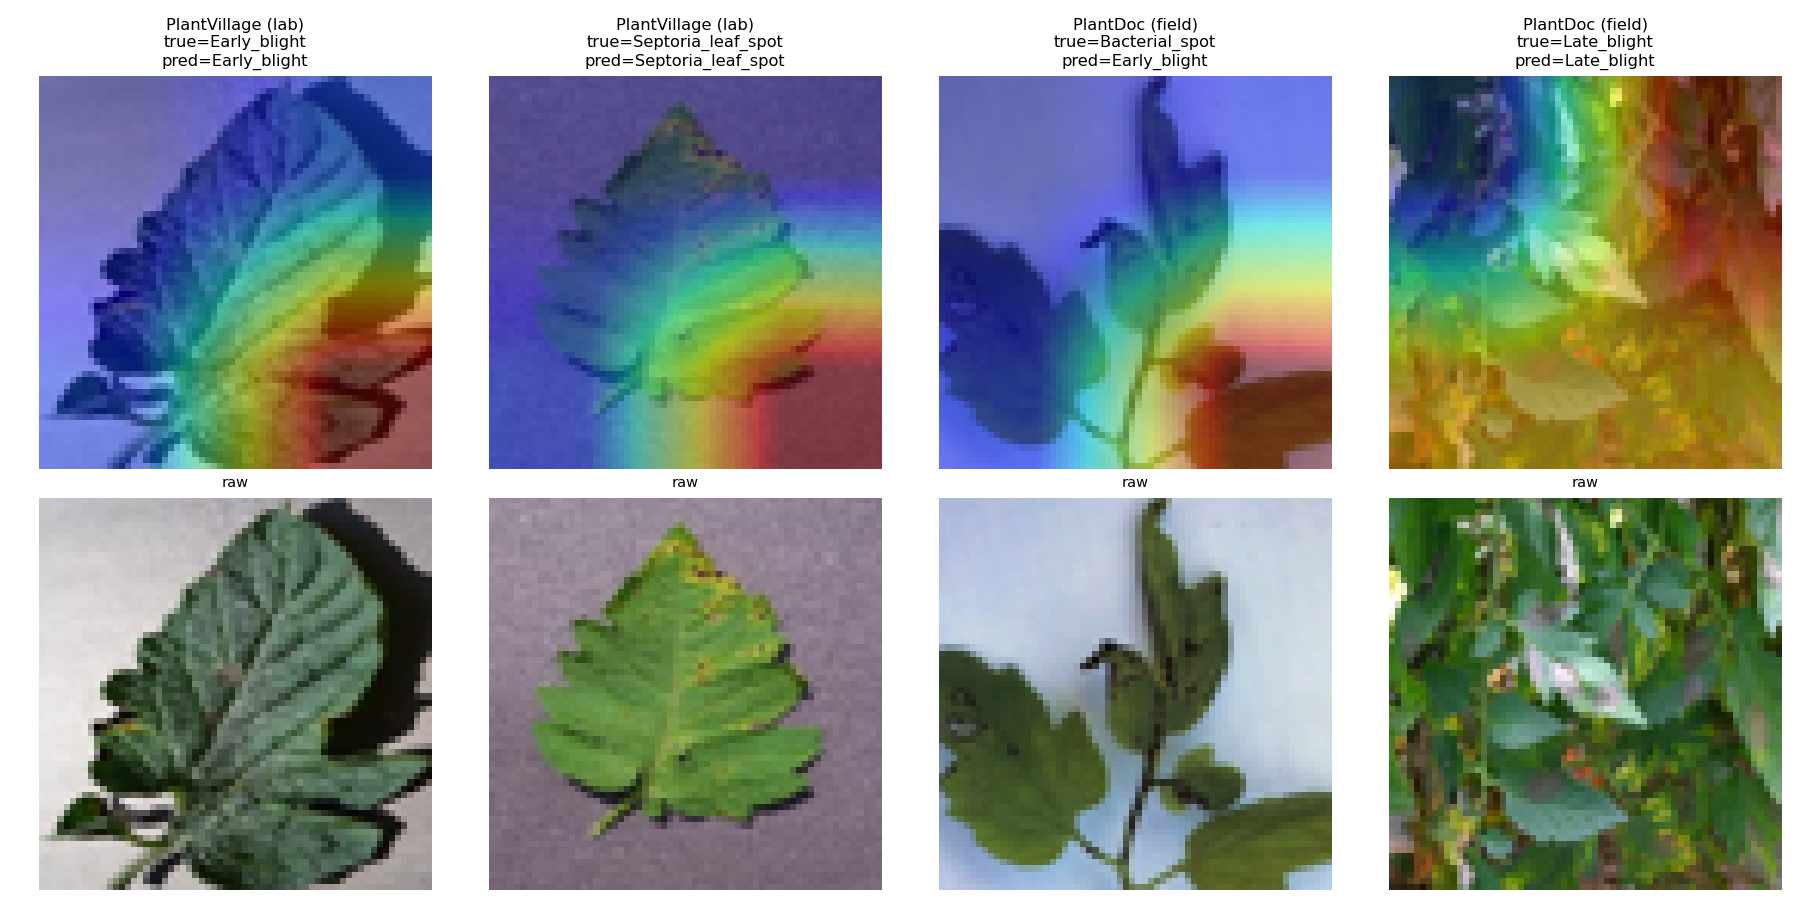

In [ ]:
# Grad-CAM on layer4 of the trained ResNet18, comparing 2 PlantVillage (lab) vs
# 2 PlantDoc (field) examples. Full implementation in gradcam.py.


On the lab images the activation is pretty focused on the leaf's diseased region, which is what you want. On the field images it spreads out more toward background structure and image borders, where PlantVillage never had much variation to learn from. That lines up with the usual explanation for why PlantVillage-trained models do not transfer well: the background was acting like a shortcut feature in the lab data, and that shortcut does not mean much in a real field photo.


## 5. RAPS conformal prediction: background

RAPS (Regularized Adaptive Prediction Sets, Angelopoulos et al. 2020) builds a prediction
set by including classes in decreasing order of predicted probability until the cumulative
probability mass (plus a small regularization penalty for classes ranked far down) exceeds
a calibrated threshold `qhat`:

$$
s(x, y) = \sum_{j:\ \hat\pi_j(x) > \hat\pi_y(x)} \hat\pi_j(x) \;+\; \hat\pi_y(x)
\;+\; \lambda \cdot \max(0,\ \text{rank}(y) - k_{\text{reg}})
$$

`qhat` is set to the `ceil((n+1)(1-alpha))/n`-quantile of these scores on a held-out
calibration set. The guarantee &mdash; `P(Y in C(X)) >= 1 - alpha` &mdash; is a *distribution-free*
result, but it relies on **exchangeability** between calibration and test data: informally,
that calibration and test points look like they came from the same shuffled deck. Domain
shift is precisely a violation of that assumption.


In [ ]:
import numpy as np

ALPHA = 0.10   # target 90% coverage
K_REG = 2
LAM = 0.05

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def raps_score(probs, labels):
    order = np.argsort(-probs, axis=1)
    ranks = np.argsort(order, axis=1)
    cumsum = np.cumsum(np.take_along_axis(probs, order, axis=1), axis=1)
    scores = np.zeros(len(labels))
    for i, y in enumerate(labels):
        r = ranks[i, y]
        scores[i] = cumsum[i, r] + LAM * max(0, (r + 1) - K_REG)
    return scores

def raps_eval(probs, labels, qhat):
    order = np.argsort(-probs, axis=1)
    cumsum = np.cumsum(np.take_along_axis(probs, order, axis=1), axis=1)
    reg = LAM * np.maximum(0, np.arange(1, probs.shape[1] + 1) - K_REG)
    covered, sizes = [], []
    for i, y in enumerate(labels):
        size = min(np.searchsorted(cumsum[i] + reg, qhat) + 1, probs.shape[1])
        sizes.append(size)
        covered.append(y in order[i, :size])
    return np.mean(covered), np.mean(sizes)

p_calib = softmax(logits_calib)
scores_calib = raps_score(p_calib, y_calib)
n = len(scores_calib)
qhat = np.quantile(scores_calib, np.ceil((n + 1) * (1 - ALPHA)) / n, method="higher")

cov_src, size_src = raps_eval(softmax(logits_test_src), y_test_src, qhat)
cov_tgt, size_tgt = raps_eval(softmax(logits_test_tgt), y_test_tgt, qhat)
print(f"In-domain coverage: {cov_src:.3f}  avg set size: {size_src:.2f}")
print(f"OOD coverage:       {cov_tgt:.3f}  avg set size: {size_tgt:.2f}")


In-domain coverage: 0.996  avg set size: 2.82
OOD coverage:       0.401  avg set size: 2.75


This is the key part. In-domain, RAPS gives 99.6% coverage against a 90% target. On PlantDoc, coverage falls to 40.1%, which is well below the nominal guarantee, at almost the same average set size (2.75 vs 2.82). The threshold learned on lab images just does not transfer, so the nominal 90% guarantee stops being reliable under shift. That is a stronger failure than the accuracy drop, because the uncertainty estimate itself is breaking.


## 6. Weighted conformal prediction: attempting a fix

Tibshirani et al. (2019) show that split conformal prediction can be extended from
i.i.d. exchangeability to **weighted exchangeability** under covariate shift: if
`w(x) = dP_target(x) / dP_source(x)` is known (or estimated), reweighting the calibration
scores by `w(x_i)` and including the test point's own weight as a point mass restores a
valid coverage guarantee under the target distribution.

$$
\hat q(x) = \inf\Big\{ s : \sum_{i=1}^n p_i(x)\, \mathbb{1}[s_i \le s] \ge 1-\alpha \Big\},
\qquad p_i(x) = \frac{w(x_i)}{\sum_{j=1}^n w(x_j) + w(x)}
$$

`w(x)` is unknown here, so I estimate it the standard way: train a logistic-regression
**domain classifier** on ResNet18 penultimate-layer embeddings (source vs. target
covariates, no labels needed for this step) and convert its output probability to a
likelihood ratio via Bayes' rule:

$$
\hat w(x) = \frac{\hat e(x)}{1-\hat e(x)} \cdot \frac{n_{\text{source pool}}}{n_{\text{target pool}}},
\qquad \hat e(x) = \hat P(\text{domain}=\text{target}\mid x)
$$


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000, C=1.0)
clf.fit(feat_pool, dom_pool)          # domain_pool covariates only, unlabeled for disease class
prior_ratio = (dom_pool == 0).sum() / (dom_pool == 1).sum()

def density_ratio(feats):
    e = np.clip(clf.predict_proba(feats)[:, 1], 1e-3, 1 - 1e-3)
    return (e / (1 - e)) * prior_ratio

w_calib = density_ratio(feat_calib)
w_test_tgt = density_ratio(feat_test_tgt)
print(f"domain classifier train accuracy: {clf.score(feat_pool, dom_pool):.3f}")
print(f"calibration weights -> mean {w_calib.mean():.2f}, median {np.median(w_calib):.2f}, "
      f"max {w_calib.max():.2f}")


domain classifier train accuracy: 0.998
calibration weights -> mean 0.20, median 0.00, max 26.93


In [ ]:
def weighted_quantile(scores_calib, w_calib, w_test_point, alpha):
    order = np.argsort(scores_calib)
    s_sorted, w_sorted = scores_calib[order], w_calib[order]
    cum_p = np.cumsum(w_sorted) / (w_sorted.sum() + w_test_point)
    idx = np.searchsorted(cum_p, 1 - alpha)
    return np.inf if idx >= len(s_sorted) else s_sorted[idx]

def weighted_raps_eval(probs, labels, w_test_all, scores_calib, w_calib, alpha):
    order = np.argsort(-probs, axis=1)
    cumsum = np.cumsum(np.take_along_axis(probs, order, axis=1), axis=1)
    reg = LAM * np.maximum(0, np.arange(1, probs.shape[1] + 1) - K_REG)
    covered, sizes = [], []
    for i, y in enumerate(labels):
        qhat_i = weighted_quantile(scores_calib, w_calib, w_test_all[i], alpha)
        size = min(np.searchsorted(cumsum[i] + reg, qhat_i) + 1, probs.shape[1])
        sizes.append(size)
        covered.append(y in order[i, :size])
    return np.mean(covered), np.mean(sizes)

cov_tgt_w, size_tgt_w = weighted_raps_eval(
    softmax(logits_test_tgt), y_test_tgt, w_test_tgt, scores_calib, w_calib, ALPHA)
print(f"OOD coverage after weighting: {cov_tgt_w:.3f}  avg set size: {size_tgt_w:.2f}")


OOD coverage after weighting: 0.969  avg set size: 7.70


Weighting does what the theory says: coverage on PlantDoc goes from 40.1% to 96.9%, above the 90% target. The tradeoff is that the average set size grows from 2.75 classes to 7.70 out of 8. The fix restores validity by making the model hedge more, not by making the base classifier much more accurate.


## 7. Why the fix is this expensive: effective sample size

Importance weighting is only informative if the weights aren't dominated by a tiny handful
of calibration points. The standard diagnostic is **effective sample size (ESS)**:

$$
\text{ESS} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}
$$


In [ ]:
w = w_calib
ess = w.sum()**2 / (w**2).sum()
print(f"calibration set size: {len(w)}")
print(f"effective sample size after reweighting: {ess:.1f}")
print(f"ESS / n: {ess/len(w):.3f}")


calibration set size: 480
effective sample size after reweighting: 6.6
ESS / n: 0.014


Out of 480 calibration points, the reweighted quantile is effectively being computed from about 6.6 of them. That is the real reason the sets get so big: the domain gap between a uniform lab background and a cluttered field photo is severe enough that only a handful of calibration images look anything like the target distribution in embedding space, so the weighted quantile has to be very conservative to stay valid with so little effective information. This is a known limitation of importance-weighted conformal prediction under large covariate shift, not a bug in the implementation.


## 8. Summary

- Accuracy drops lab-to-field (94.1% → 17.2%), which matches what other work on PlantVillage → PlantDoc has found.
- The RAPS coverage guarantee drops too (99.6% → 40.1%), which is a sharper problem than the accuracy drop alone.
- Weighted conformal prediction brings coverage back up (96.9%), but the price is larger sets, and the effective-sample-size number explains why.
- If I were to push this further, I would try to reduce the domain gap before calibration, for example with domain-invariant features or a bit more field-style data. Weighted conformal prediction is useful for quantifying the problem, but it is not a fix by itself.

## Reproducibility

This notebook ran end-to-end on CPU (no GPU, 1 core) in about 10 minutes for training plus under a minute for calibration/Grad-CAM/weighting, using 64x64 images and a from-scratch ResNet18 as a deliberately small same-day proof of concept. On a GPU environment (Colab/Kaggle) with pretrained ImageNet weights and higher resolution, both the in-domain accuracy and the raw numbers would likely improve, but the qualitative finding (coverage collapse under shift, partial and expensive repair via weighting) is a structural property of the domain gap, not an artifact of under-training.

Datasets: [PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset), [PlantDoc](https://github.com/pratikkayal/PlantDoc-Dataset). Method: Tibshirani, R. et al. (2019), *Conformal Prediction Under Covariate Shift*, NeurIPS. Angelopoulos, A. et al. (2020), *Uncertainty Sets for Image Classifiers Using Conformal Prediction*.
